<h1><font color="#113D68" size=6>Deep Learning en Python con PyTorch</font></h1>

<h1><font color="#113D68" size=5>Parte 3. Multilayer Perceptron</font></h1>

<h1><font color="#113D68" size=4>6. Proyecto de clasificación multiclase</font></h1>

<br><br>
<div style="text-align: right">
<font color="#113D68" size=3>Manuel Castillo Cara</font><br>

</div>

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
More information about [Manuel Castillo-Cara](https://www.manuelcastillo.eu/)

<div class="alert alert-block alert-info">

<i class="fa fa-info-circle" aria-hidden="true"></i>
Puedes ver más cursos de Inteligencia Artificial, Machine Learning y Deep Learning en mi [página web](https://www.manuelcastillo.eu/udemy/)


---

<a id="indice"></a>
<h2><font color="#004D7F" size=5>Índice</font></h2>

* [0. Contexto](#section0)
* [1. Descripción del Problema](#section1)
* [2. Cargar el Conjunto de Datos](#section2)
* [3. Codificar la Variable Categórica](#section3)
* [4. Definir el Modelo de Red Neuronal](#section4)
* [5. Evaluar el modelo](#section5)

---
<a id="section0"></a>
# <font color="#004D7F" size=6> 0. Contexto</font>

La biblioteca PyTorch es utilizada para el aprendizaje profundo. Algunas aplicaciones de modelos de aprendizaje profundo se utilizan para resolver problemas de regresión o clasificación. En este capítulo, descubrirás cómo usar PyTorch para desarrollar y evaluar modelos de redes neuronales para problemas de clasificación multiclase. Después de completar este tutorial paso a paso, sabrás:

- Cómo cargar datos desde un archivo CSV y hacerlos disponibles para PyTorch.
- Cómo preparar datos de clasificación multiclase para modelado con redes neuronales.
- Cómo usar la validación cruzada para evaluar un modelo de red neuronal en PyTorch.

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section1"></a>
# <font color="#004D7F" size=6>1. Descripción del Problema</font>

- Se utilizará el conjunto de datos Iris, un estándar en aprendizaje automático.

- Características del conjunto de datos Iris:
  
  - Cuatro variables de entrada numéricas (longitudes en centímetros).
  
  - Escala similar entre las variables.
  
  - Cada muestra describe propiedades de una flor de iris.

- Objetivo: Clasificar la especie de iris basándose en las mediciones.

- Tipo de problema: Clasificación multiclase (tres especies de iris).

- Rendimiento esperado: Accuracy del modelo entre 95% y 97%.

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre el dataset [Iris](https://archive.ics.uci.edu/ml/datasets/Iris)

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section2"></a>
# <font color="#004D7F" size=6>2. Cargar el Conjunto de Datos</font>

- Después de leer el conjunto de datos, es necesario dividirlo en características y etiquetas.

- Las etiquetas requieren procesamiento antes de su uso.

- A diferencia de NumPy o PyTorch, los DataFrames de pandas utilizan `iloc` para realizar cortes.
    - `X` contiene todas las filas y todas las columnas excepto la última (características).
    - `y` contiene todas las filas de la última columna (etiquetas).

In [1]:
# Descarga de datos (necesario en Colab): se guardan en ./Datasets
import os, urllib.request

os.makedirs('Datasets', exist_ok=True)
urls = {
    'iris.csv':
        'https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv',
}
for nombre, url in urls.items():
    if not os.path.exists(f'Datasets/{nombre}'):
        urllib.request.urlretrieve(url, f'Datasets/{nombre}')

In [2]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

data = pd.read_csv("Datasets/iris.csv", header=None)
X = data.iloc[:, 0:4].astype(float)
y = data[[4]]
y

,4
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa
...,...
145,Iris-virginica
146,Iris-virginica
147,Iris-virginica
148,Iris-virginica


---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section3"></a>
# <font color="#004D7F" size=6>3. Codificar la Variable Categórica</font>

- En este conjunto de datos, las tres etiquetas de clase son _Iris-setosa_, _Iris-versicolor_ e _Iris-virginica_. 

- Una forma de convertir estas etiquetas en un número (es decir, codificarlas) es simplemente asignar un valor entero, como 0, 1 o 2, para reemplazar estas etiquetas. 

- Hay que codifcarlo a un vector one-hot es un vector de enteros, pero solo uno de ellos es 1 y los demás son todos cero. 

- En este caso, conviertes las etiquetas en lo siguiente:

```
    Iris-setosa      1 0 0
    Iris-versicolor  0 1 0
    Iris-virginica   0 0 1
```

Vamos a codificarlo con la función `OneHotEncoder`:

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html).

In [3]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(y)
y = ohe.transform(y)
y

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

- Proceso:
  - Dividir el conjunto de datos en entrenamiento y test.
  - Usar el conjunto de test para evaluar el modelo al final del entrenamiento.

- Propósitos de la evaluación:
  1. Medir el rendimiento en datos no vistos.
  2. Evitar el sobreajuste (overfitting).

- El argumento `train_size=0.7` con `shuffle=True` significa que se seleccionarán aleatoriamente el 70% para train y el 30% de test.

In [4]:
X = torch.tensor(X.values, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section4"></a>
# <font color="#004D7F" size=6>4. Definir el Modelo de Red Neuronal</font>

- Requisitos del modelo:
  - Entrada: vector de 4 características
  - Salida: vector de 3 valores (correspondiente al vector one-hot)

- Las capas entre la entrada y la salida se conocen como "capas ocultas".

- Diseño simple propuesto:
  - 4 entradas
  - 8 nodos ocultos
  - 3 salidas

- Se recomienda usar activación softmax en la capa de salida. Su formalización es:
  $$\sigma(z_i) = \frac{e^{z_i}}{\sum_{j=1}^3 e^{z_j}}$$

- Características de la función softmax:
  - Normaliza los valores de salida
  - La suma de las 3 salidas será 1
  - Cada salida estará en el rango de 0 a 1
  - Hace que la salida se asemeje a un vector de probabilidades

> **Actualización:** `nn.CrossEntropyLoss` ya aplica `log_softmax` internamente, por lo que la red debe devolver los **logits** (sin `Softmax` en la última capa). Si quieres probabilidades, aplica `torch.softmax(y_pred, dim=1)` solo al hacer inferencia.

In [5]:
class Multiclass(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(4, 8)
        self.act = nn.ReLU()
        self.output = nn.Linear(8, 3)  # 3 clases: devuelve logits

    def forward(self, x):
        x = self.act(self.hidden(x))
        x = self.output(x)
        return x

- Métrica de pérdida: entropía cruzada categórica: `CrossEntropyLoss`.

- Fórmula de entropía cruzada:

  $$H(p, q) = -\sum_x p(x) \log q(x)$$
    
    - $p(x)$: vector de probabilidad real (one-hot)

    - $q(x)$: vector de probabilidad predicha (salida del modelo)

- Para vectores one-hot, solo la clase real tiene $p(x) = 1$, las demás $p(x) = 0$.

- La suma se reduce a $-\log q(x)$ de la clase real.

    - Valor mínimo (mejor): 0 cuando $q(x) = 1$
    
    - Valor máximo (peor): infinito cuando $q(x)$ se acerca a 0

- Se elige Adam como optimizador con una tasa de aprendizaje de 0.01.

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre [`CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre [`softmax`](https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html).

In [6]:
model = Multiclass()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section5"></a>
# <font color="#004D7F" size=6>5. Evaluar el modelo</font>

Aspectos clave para el bucle de evaluación del modelo:

1. Actualización de parámetros del optimizador:
   
   - Indicar los parámetros del modelo al definir el optimizador.
   
   - Estos son los parámetros que el optimizador actualizará.

2. Bucle de entrenamiento:
   
   - Pase hacia adelante: proporciona entrada al modelo y toma la salida.
   
   - Pase hacia atrás: propaga el gradiente desde la métrica de pérdida hasta la entrada.
   
   - Actualización de pesos: basada en el gradiente calculado.

3. Evaluación en test:
   - Usar conjunto de entrenamiento durante el entrenamiento.
   
   - Utilizar conjunto de test al final de cada época para evaluación.

4. Guardar el mejor modelo:
   
   - Restaurar el modelo al mejor rendimiento logrado.
   
   - Generar gráfico para visualizar progreso de entropía cruzada y accuracy.

5. Implementación de mejoras:
   - Registrar accuracy en conjunto de test.
   
   - Guardar copia del modelo cuando mejora el accuracy.
   
   - Almacenar métricas calculadas en una lista.
   
   - Al final, restaurar el mejor modelo obtenido.
   
   - Trazar métricas como serie temporal.

In [7]:
# prepare model and training parameters
n_epochs = 200
batch_size = 5
batches_per_epoch = len(X_train) // batch_size

best_acc = -np.inf
best_weights = None
train_loss_hist = []
train_acc_hist = []
test_loss_hist = []
test_acc_hist = []

# training loop
for epoch in range(n_epochs):
    epoch_loss = []
    epoch_acc = []
    model.train()
    with tqdm.trange(batches_per_epoch, unit="batch", mininterval=0) as bar:
        bar.set_description(f"Epoch {epoch}")
        for i in bar:
            # take a batch
            start = i * batch_size
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # compute and store metrics
            acc = (torch.argmax(y_pred, 1) == torch.argmax(y_batch, 1)).float().mean()
            epoch_loss.append(float(loss))
            epoch_acc.append(float(acc))
            bar.set_postfix(
                loss=float(loss),
                acc=float(acc)
            )
    # set model in evaluation mode and run through the test set
    model.eval()
    y_pred = model(X_test)
    ce = loss_fn(y_pred, y_test)
    acc = (torch.argmax(y_pred, 1) == torch.argmax(y_test, 1)).float().mean()
    ce = float(ce)
    acc = float(acc)
    # save best model
    train_loss_hist.append(np.mean(epoch_loss))
    train_acc_hist.append(np.mean(epoch_acc))
    test_loss_hist.append(ce)
    test_acc_hist.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_weights = copy.deepcopy(model.state_dict())
    print(f"Epoch {epoch} validation: Cross-entropy={ce:.2f}, Accuracy={acc*100:.1f}%")

  0%|          | 0/21 [00:00<?, ?batch/s]

Epoch 0:   0%|          | 0/21 [00:00<?, ?batch/s]

/tmp/ipykernel_440297/1205116262.py:35: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  epoch_loss.append(float(loss))
Epoch 0:   0%|          | 0/21 [00:00<?, ?batch/s, acc=0.2, loss=1.59]

Epoch 0:   5%|▍         | 1/21 [00:00<00:00, 29.63batch/s, acc=0.2, loss=1.59]

Epoch 0:   5%|▍         | 1/21 [00:00<00:00, 29.63batch/s, acc=0.6, loss=1.09]

...

Epoch 199:  95%|█████████▌| 20/21 [00:00<00:00, 692.63batch/s, acc=1, loss=0.00146]

Epoch 199:  95%|█████████▌| 20/21 [00:00<00:00, 692.63batch/s, acc=1, loss=0.101]  

Epoch 199: 100%|██████████| 21/21 [00:00<00:00, 707.59batch/s, acc=1, loss=0.101]

Epoch 199: 100%|██████████| 21/21 [00:00<00:00, 721.71batch/s, acc=1, loss=0.101]

Epoch 199 validation: Cross-entropy=0.07, Accuracy=97.8%


Restauramos el mejor modelo.

In [8]:
model.load_state_dict(best_weights)

<All keys matched successfully>

Finalmente, puedes graficar la pérdida y la precisión a lo largo de las épocas utilizando `matplotlib` de la siguiente manera:

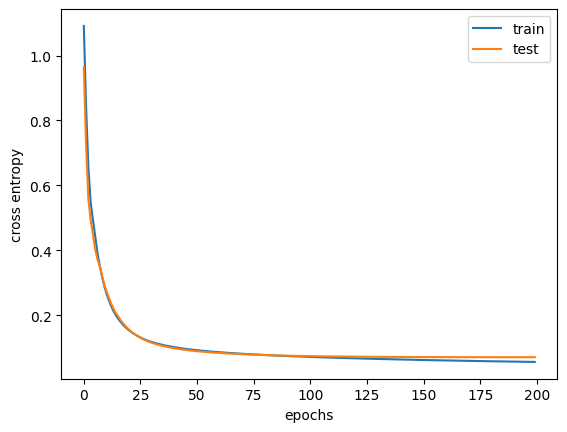

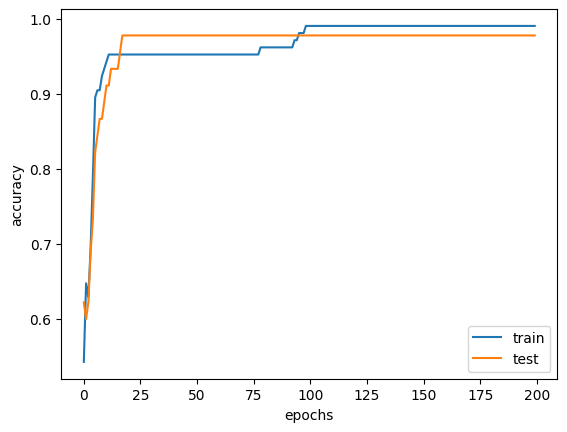

In [9]:
# Plot the loss and accuracy
plt.plot(train_loss_hist, label="train")
plt.plot(test_loss_hist, label="test")
plt.xlabel("epochs")
plt.ylabel("cross entropy")
plt.legend()
plt.show()

plt.plot(train_acc_hist, label="train")
plt.plot(test_acc_hist, label="test")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()

<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<div style="text-align: right"> <font size=6><i class="fa fa-coffee" aria-hidden="true" style="color:#004D7F"></i> </font></div>